# MGTAB Bot Detection\n**Architecture**: LightGBM + XGBoost + Random Forest Ensemble with Threshold Tuning\n**Data**: PyTorch Tensor Node Features (788-dim)

## Cell 1 — Install Dependencies

In [1]:
!pip install torch lightgbm xgboost catboost scikit-learn pandas numpy matplotlib seaborn -q


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: pip install --upgrade pip


## Cell 2 — Imports & Seed

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
import os
import torch

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix,
    ConfusionMatrixDisplay, precision_recall_curve
)
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from xgboost import XGBClassifier
import lightgbm as lgb
from catboost import CatBoostClassifier

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
print('All imports OK')

All imports OK


## Cell 3 — Load MGTAB Data

In [3]:
# Load PyTorch tensors
DATA_DIR = 'data/MGTAB/'

features_tensor = torch.load(os.path.join(DATA_DIR, 'features.pt'))
labels_tensor = torch.load(os.path.join(DATA_DIR, 'labels_bot.pt'))

print('Features shape:', features_tensor.shape)
print('Labels shape:', labels_tensor.shape)

# Convert to NumPy for Scikit-Learn / LightGBM / XGBoost
X = features_tensor.numpy()
y = labels_tensor.numpy()

# Check label distribution
unique, counts = np.unique(y, return_counts=True)
print('\nLabel distribution:')
for u, c in zip(unique, counts):
    print(f'Label {u}: {c}')
X = X[:len(y)]

Features shape: torch.Size([10199, 788])
Labels shape: torch.Size([10199])

Label distribution:
Label 0: 7451
Label 1: 2748


## Cell 4 — Train/Val/Test Split

In [4]:
# Using a 70/15/15 split
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.15, random_state=SEED, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.1765, random_state=SEED, stratify=y_temp)

print(f'Train samples: {X_train.shape[0]}')
print(f'Val samples:   {X_val.shape[0]}')
print(f'Test samples:  {X_test.shape[0]}')

Train samples: 7138
Val samples:   1531
Test samples:  1530


## Cell 5 — Feature Scaling

In [5]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val   = scaler.transform(X_val)
X_test  = scaler.transform(X_test)

num_bots   = (y_train == 1).sum()
num_humans = (y_train == 0).sum()
scale_w    = num_humans / num_bots

print(f'Bots in Train: {num_bots}')
print(f'Humans in Train: {num_humans}')
print(f'scale_pos_weight: {scale_w:.4f}')

Bots in Train: 1923
Humans in Train: 5215
scale_pos_weight: 2.7119


## Cell 6 — Train LightGBM

In [6]:
lgb_model = lgb.LGBMClassifier(
    n_estimators      = 1000,
    learning_rate     = 0.05,
    num_leaves        = 31,
    max_depth         = -1,
    scale_pos_weight  = scale_w,
    random_state      = SEED,
    n_jobs            = -1,
    verbose           = -1
)

lgb_model.fit(
    X_train, y_train,
    eval_set  = [(X_val, y_val)],
    callbacks = [
        lgb.early_stopping(stopping_rounds=50, verbose=False),
        lgb.log_evaluation(period=100)
    ]
)
print(f'Best iteration: {lgb_model.best_iteration_}')

[100]	valid_0's binary_logloss: 0.194531
Best iteration: 106


## Cell 7 — Train XGBoost

In [7]:
xgb_model = XGBClassifier(
    n_estimators          = 1000,
    learning_rate         = 0.05,
    max_depth             = 6,
    scale_pos_weight      = scale_w,
    eval_metric           = 'logloss',
    early_stopping_rounds = 50,
    random_state          = SEED,
    n_jobs                = -1,
    verbosity             = 0
)

xgb_model.fit(
    X_train, y_train,
    eval_set = [(X_val, y_val)],
    verbose  = 100
)
print(f'Best iteration: {getattr(xgb_model, "best_iteration", getattr(xgb_model, "best_ntree_limit", "N/A"))}')

[0]	validation_0-logloss:0.65811
[100]	validation_0-logloss:0.20678
[200]	validation_0-logloss:0.20341
Best iteration: 150


## Cell 8 — Train Random Forest

In [8]:
rf_model = RandomForestClassifier(
    n_estimators     = 300,
    max_depth        = None,
    class_weight     = 'balanced_subsample',
    random_state     = SEED,
    n_jobs           = -1
)

rf_model.fit(X_train, y_train)
print('Random Forest trained')

Random Forest trained


## Cell 8a — Train CatBoost

In [9]:
cb_model = CatBoostClassifier(
    n_estimators      = 1000,
    learning_rate     = 0.05,
    depth             = 6,
    scale_pos_weight  = scale_w,
    random_state      = SEED,
    verbose           = False,
    thread_count      = -1
)

cb_model.fit(X_train, y_train, eval_set=(X_val, y_val))
print('CatBoost trained')

CatBoost trained


## Cell 8b — Train Logistic Regression

In [10]:
lr_model = LogisticRegression(
    random_state = SEED,
    class_weight = 'balanced',
    max_iter     = 1000
)

lr_model.fit(X_train, y_train)
print('Logistic Regression trained')

Logistic Regression trained


## Cell 8c — Train Extra Trees

In [11]:
et_model = ExtraTreesClassifier(
    n_estimators     = 300,
    class_weight     = 'balanced',
    random_state     = SEED,
    n_jobs           = -1
)

et_model.fit(X_train, y_train)
print('Extra Trees trained')

Extra Trees trained


## Cell 8d — Train MLP

In [12]:
mlp_model = MLPClassifier(
    hidden_layer_sizes = (128, 64),
    max_iter           = 500,
    random_state       = SEED
)

mlp_model.fit(X_train, y_train)
print('MLP trained')

MLP trained


## Cell 9 — Ensemble + Threshold Tuning (Validation Set)

Optimal threshold : 0.4134
Val Precision     : 0.8117
Val Recall        : 0.9395
Val F1            : 0.8709


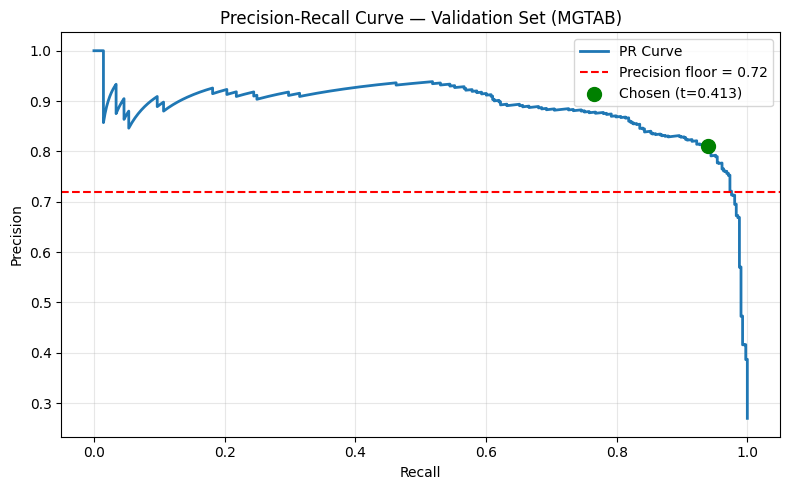

In [13]:
# Soft vote ensemble on validation set
lgb_val = lgb_model.predict_proba(X_val)[:, 1]
xgb_val = xgb_model.predict_proba(X_val)[:, 1]
rf_val  = rf_model.predict_proba(X_val)[:, 1]
cb_val  = cb_model.predict_proba(X_val)[:, 1]
lr_val  = lr_model.predict_proba(X_val)[:, 1]
et_val  = et_model.predict_proba(X_val)[:, 1]
mlp_val = mlp_model.predict_proba(X_val)[:, 1]

val_probs = (lgb_val + xgb_val + rf_val + cb_val + lr_val + et_val + mlp_val) / 7.0

# --- Threshold tuning ---
PRECISION_FLOOR = 0.72   # lower this if recall is too low, raise to boost precision

precision_arr, recall_arr, thresholds = precision_recall_curve(y_val, val_probs)

best_thresh = 0.5
best_f1     = 0.0

for p, r, t in zip(precision_arr[:-1], recall_arr[:-1], thresholds):
    if p >= PRECISION_FLOOR:
        f = 2 * p * r / (p + r + 1e-9)
        if f > best_f1:
            best_f1     = f
            best_thresh = t

val_preds = (val_probs >= best_thresh).astype(int)

print(f'Optimal threshold : {best_thresh:.4f}')
print(f'Val Precision     : {precision_score(y_val, val_preds):.4f}')
print(f'Val Recall        : {recall_score(y_val, val_preds):.4f}')
print(f'Val F1            : {f1_score(y_val, val_preds):.4f}')

# Plot PR curve
plt.figure(figsize=(8, 5))
plt.plot(recall_arr, precision_arr, lw=2, label='PR Curve')
plt.axhline(y=PRECISION_FLOOR, color='red', linestyle='--', label=f'Precision floor = {PRECISION_FLOOR}')
plt.scatter([recall_score(y_val, val_preds)],
            [precision_score(y_val, val_preds)],
            color='green', zorder=5, s=100, label=f'Chosen (t={best_thresh:.3f})')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve — Validation Set (MGTAB)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('mgtab_pr_curve.png', dpi=150)
plt.show()

## Cell 10 — Final Evaluation on Test Set

             MULTI-MODEL COMPARISON (TEST SET)      
                     Accuracy  Precision  Recall  F1 Score  AUC-ROC
LightGBM               0.9183     0.7842  0.9612    0.8637   0.9807
XGBoost                0.9157     0.7824  0.9515    0.8587   0.9794
Random Forest          0.9124     0.8441  0.8277    0.8358   0.9574
CatBoost               0.9150     0.7743  0.9660    0.8596   0.9806
Logistic Regression    0.8915     0.7402  0.9199    0.8203   0.9512
Extra Trees            0.8869     0.7825  0.8034    0.7928   0.9416
MLP                    0.9059     0.8350  0.8107    0.8227   0.9546
Ensemble               0.9248     0.8075  0.9466    0.8715   0.9762


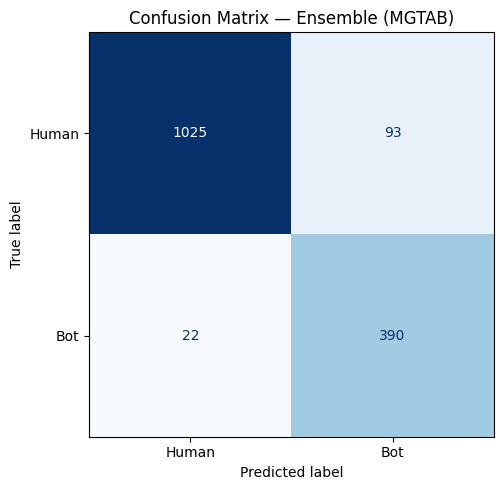

In [14]:
# Ensemble on test set
lgb_test  = lgb_model.predict_proba(X_test)[:, 1]
xgb_test  = xgb_model.predict_proba(X_test)[:, 1]
rf_test   = rf_model.predict_proba(X_test)[:, 1]
cb_test   = cb_model.predict_proba(X_test)[:, 1]
lr_test   = lr_model.predict_proba(X_test)[:, 1]
et_test   = et_model.predict_proba(X_test)[:, 1]
mlp_test  = mlp_model.predict_proba(X_test)[:, 1]

test_probs = (lgb_test + xgb_test + rf_test + cb_test + lr_test + et_test + mlp_test) / 7.0

# Get hard predictions for all models
lgb_preds = (lgb_test >= best_thresh).astype(int)
xgb_preds = (xgb_test >= best_thresh).astype(int)
rf_preds  = (rf_test >= best_thresh).astype(int)
cb_preds  = (cb_test >= best_thresh).astype(int)
lr_preds  = (lr_test >= best_thresh).astype(int)
et_preds  = (et_test >= best_thresh).astype(int)
mlp_preds = (mlp_test >= best_thresh).astype(int)
ens_preds = (test_probs >= best_thresh).astype(int)

# Compile results
def get_metrics(y_true, y_pred, y_prob):
    return {
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred),
        'Recall': recall_score(y_true, y_pred),
        'F1 Score': f1_score(y_true, y_pred),
        'AUC-ROC': roc_auc_score(y_true, y_prob)
    }

results = {
    'LightGBM': get_metrics(y_test, lgb_preds, lgb_test),
    'XGBoost': get_metrics(y_test, xgb_preds, xgb_test),
    'Random Forest': get_metrics(y_test, rf_preds, rf_test),
    'CatBoost': get_metrics(y_test, cb_preds, cb_test),
    'Logistic Regression': get_metrics(y_test, lr_preds, lr_test),
    'Extra Trees': get_metrics(y_test, et_preds, et_test),
    'MLP': get_metrics(y_test, mlp_preds, mlp_test),
    'Ensemble': get_metrics(y_test, ens_preds, test_probs)
}

results_df = pd.DataFrame(results).T
print("=" * 60)
print("             MULTI-MODEL COMPARISON (TEST SET)      ")
print("=" * 60)
print(results_df.round(4))
print("=" * 60)

# Confusion matrix for Ensemble
cm   = confusion_matrix(y_test, ens_preds)
disp = ConfusionMatrixDisplay(cm, display_labels=['Human', 'Bot'])
fig, ax = plt.subplots(figsize=(6, 5))
disp.plot(ax=ax, cmap='Blues', colorbar=False)
plt.title('Confusion Matrix — Ensemble (MGTAB)')
plt.tight_layout()
plt.savefig('mgtab_confusion_matrix.png', dpi=150)
plt.show()